# MP-Hunter: Unsupervised Malicious Package Detection

Implementation theo pipeline của Liang et al. (2023) — *"A needle is an outlier in a haystack: Hunting malicious PyPI packages with code clustering"*

**Pipeline:**
1. **APIEM v2** — Trích xuất API call sequence từ AST + suspicious string patterns + ENV access
2. **CCEM** — Train FastText (skip-gram, vector_size=256, epochs=30)
3. **K-Means clustering** — k=8, cluster trên embedding vectors
4. **Evaluation** — Accuracy, Precision, Recall, F1 theo Table 2 bài báo LAMPS

**Cải tiến so với phiên bản trước:**
- Fix bug alpha decay: train FastText đúng cách với `sentences=` thay vì epoch-by-epoch
- APIEM v2: thêm suspicious string literals (`http`, `base64`, `powershell`...) và ENV access patterns
- vector_size tăng từ 128 → 256, epochs tăng từ 15 → 30
- k=21 (chọn theo val set)
- Data: stratified split sạch (dedup + balanced)

**Kết quả:** Val Acc=93.77% F1=0.936 | Test Acc=96.05% F1=0.960

## 1. Setup

In [ ]:
import ast
import json
import numpy as np
import warnings
warnings.filterwarnings('ignore')

!pip install gensim -q
from gensim.models import FastText
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix
)
from scipy.stats import mode

np.random.seed(42)
print('Setup complete')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.1 MB/s eta 0:00:00
Setup complete


## 2. Configuration

| Hyperparameter | Giá trị | Lý do |
|---|---|---|
| `vector_size` | **256** | Tăng từ 128 → capture được nhiều semantic patterns hơn với vocab ~4600 tokens |
| `window` | 5 | Standard cho skip-gram, capture context API calls |
| `epochs` | **30** | Tăng từ 15 → embedding hội tụ tốt hơn; không overfit vì unsupervised |
| `sg` | 1 | Skip-gram tốt hơn CBOW cho rare/obfuscated API tokens |
| `n_clusters` | **21** | Tốt nhất trên val set; tách fine-grained malicious behavior types |

In [ ]:
CONFIG = {
    # FastText / CCEM
    'vector_size': 256,    # tăng từ 128
    'window'     : 5,
    'min_count'  : 1,
    'epochs'     : 30,     # tăng từ 15
    'sg'         : 1,      # skip-gram
    'seed'       : 42,

    # K-Means
    'n_clusters' : 21,     # chọn theo val F1 trên dataset này
    'n_init'     : 10,

    # Paths
    'train_path' : 'train.jsonl',
    'val_path'   : 'val.jsonl',
    'test_path'  : 'test.jsonl',
}

for k, v in CONFIG.items():
    print(f'  {k}: {v}')

  vector_size: 256
  window: 5
  min_count: 1
  epochs: 30
  sg: 1
  seed: 42
  n_clusters: 21
  n_init: 10
  train_path: train.jsonl
  val_path: val.jsonl
  test_path: test.jsonl


## 3. Google Drive Mount & Paths (Colab)

In [ ]:
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR   = Path('/content/drive/MyDrive/LAMPS')
DATA_DIR   = BASE_DIR / 'data'
OUTPUT_DIR = BASE_DIR / 'mphunter_output'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_FILE = DATA_DIR / CONFIG['train_path']
VAL_FILE   = DATA_DIR / CONFIG['val_path']
TEST_FILE  = DATA_DIR / CONFIG['test_path']

print(f'Data dir   : {DATA_DIR}')
print(f'Output dir : {OUTPUT_DIR}')
print(f'Train file : {TRAIN_FILE}')

Mounted at /content/drive
Data dir   : /content/drive/MyDrive/LAMPS/data
Output dir : /content/drive/MyDrive/LAMPS/mphunter_output
Train file : /content/drive/MyDrive/LAMPS/data/train.jsonl


## 4. Load Data

In [ ]:
def load_jsonl(filepath):
    """Load JSONL dataset"""
    data = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                data.append(json.loads(line.strip()))
            except:
                continue
    return data

def prepare_data(data):
    """Extract codes and labels from dataset"""
    codes = [item['func'] for item in data]
    labels = [item['target'] for item in data]
    return codes, labels

# Load datasets
print("Loading datasets...")
train_data = load_jsonl(TRAIN_FILE)
val_data = load_jsonl(VAL_FILE)
test_data = load_jsonl(TEST_FILE)

# Extract codes and labels
train_codes, train_labels = prepare_data(train_data)
val_codes, val_labels = prepare_data(val_data)
test_codes, test_labels = prepare_data(test_data)

# Display statistics
print("\n" + "="*70)
print("DATASET STATISTICS")
print("="*70)
print(f"Train set: {len(train_codes)} samples")
print(f"  - Benign:    {train_labels.count(0)} ({train_labels.count(0)/len(train_labels)*100:.1f}%)")
print(f"  - Malicious: {train_labels.count(1)} ({train_labels.count(1)/len(train_labels)*100:.1f}%)")
print(f"\nValidation set: {len(val_codes)} samples")
print(f"Test set: {len(test_codes)} samples")
print("="*70)

print("\n✓ Data loaded successfully!")

Loading datasets...

DATASET STATISTICS
Train set: 4242 samples
  - Benign:    2121 (50.0%)
  - Malicious: 2121 (50.0%)

Validation set: 530 samples
Test set: 532 samples

✓ Data loaded successfully!


## 5. Phân tách Empty vs Non-empty setup.py

Dataset chứa các **typosquatting packages** có `setup.py` trống (ví dụ: `diiscord-webhook`, `xlsxxwriter`, `python-binanc`). Đây là tấn công mà malicious logic nằm trong `__init__.py`, không phải `setup.py`. Trong toàn bộ dataset, **100% empty setup.py = malicious** → detect trực tiếp, không cần clustering.

In [ ]:
def split_empty_nonempty(data):
    empty    = [d for d in data if d['func'].strip() == '']
    nonempty = [d for d in data if d['func'].strip() != '']
    return empty, nonempty

train_empty, train_ne = split_empty_nonempty(train_data)
val_empty,   val_ne   = split_empty_nonempty(val_data)
test_empty,  test_ne  = split_empty_nonempty(test_data)

for name, empty in [('Train', train_empty), ('Val', val_empty), ('Test', test_empty)]:
    all_mal = all(d['target'] == 1 for d in empty) if empty else True
    print(f'{name}: {len(empty)} empty samples | all malicious: {all_mal}')

print(f'\nNon-empty for clustering — Train: {len(train_ne)} | Val: {len(val_ne)} | Test: {len(test_ne)}')

Train: 0 empty samples | all malicious: True
Val: 0 empty samples | all malicious: True
Test: 0 empty samples | all malicious: True

Non-empty for clustering — Train: 4242 | Val: 530 | Test: 532


## 6. APIEM v2 — API Encoding Model

Parse AST và trích xuất **canonical API call sequence**.

**v2 bổ sung so với v1:**
- **Suspicious string literals**: detect các string chứa `http`, `base64`, `powershell`, `/bin/`, `/tmp/`, `exec`... → thêm token `STR_HTTP`, `STR_BASE64`...
- **ENV access pattern**: detect `os.environ`, `os.getenv` → thêm token `ENV_ACCESS`

Những signals này xuất hiện nhiều trong malicious code (download payload, execute commands) nhưng hiếm trong benign packages.

In [ ]:
# Suspicious keywords trong string literals → behavioral indicators
SUSPICIOUS_STR_KW = [
    'http', 'ftp', 'socket', '/bin/', '/tmp',
    'cmd', 'powershell', 'base64', 'wget', 'curl', 'exec'
]

def extract_api_sequence(code: str) -> list:
    """
    APIEM v2: Trích xuất canonical API sequence từ setup.py.

    Tokens:
    - import os            → 'imp_os'
    - from sub import Popen→ 'frm_subprocess' + 'fn_Popen'
    - obj.method()         → 'method' + 'obj_method'
    - func()               → 'func'
    - string 'http://...'  → 'STR_HTTP'          [v2]
    - os.environ           → 'ENV_ACCESS'         [v2]
    """
    apis = []
    try:
        tree = ast.parse(code)
        for node in ast.walk(tree):

            # Import: `import os` → 'imp_os'
            if isinstance(node, ast.Import):
                for alias in node.names:
                    apis.append('imp_' + alias.name.replace('.', '_'))

            # From-import: `from subprocess import Popen`
            elif isinstance(node, ast.ImportFrom):
                mod = node.module or ''
                apis.append('frm_' + mod.replace('.', '_'))
                for alias in node.names:
                    if alias.name != '*':
                        apis.append('fn_' + alias.name)

            # Function/method calls
            elif isinstance(node, ast.Call):
                if isinstance(node.func, ast.Attribute):
                    apis.append(node.func.attr)
                    if isinstance(node.func.value, ast.Name):
                        apis.append(node.func.value.id + '_' + node.func.attr)
                elif isinstance(node.func, ast.Name):
                    apis.append(node.func.id)

            # [v2] String literal suspicious patterns
            elif isinstance(node, ast.Constant):
                try:
                    s = str(node.value).lower()
                    for kw in SUSPICIOUS_STR_KW:
                        if kw in s:
                            apis.append('STR_' + kw.upper().replace('/', '_'))
                            break  # chỉ thêm 1 token per string
                except Exception:
                    pass

            # [v2] ENV access pattern: os.environ, os.getenv
            elif isinstance(node, ast.Attribute) and node.attr in ('environ', 'getenv'):
                apis.append('ENV_ACCESS')

    except SyntaxError:
        pass

    return apis if apis else ['NO_API']


# Áp dụng APIEM v2
train_seqs = [extract_api_sequence(d['func']) for d in train_ne]
val_seqs   = [extract_api_sequence(d['func']) for d in val_ne]
test_seqs  = [extract_api_sequence(d['func']) for d in test_ne]

train_labels_ne = np.array([d['target'] for d in train_ne])
val_labels_ne   = np.array([d['target'] for d in val_ne])
test_labels_ne  = np.array([d['target'] for d in test_ne])

seq_lens = [len(s) for s in train_seqs]
print(f'API sequence length — min:{min(seq_lens)} max:{max(seq_lens)} avg:{np.mean(seq_lens):.1f}')
print(f'\nSample malicious : {train_seqs[next(i for i,d in enumerate(train_ne) if d["target"]==1)][:8]}')
print(f'Sample benign    : {train_seqs[next(i for i,d in enumerate(train_ne) if d["target"]==0)][:8]}')

API sequence length — min:1 max:604 avg:22.1

Sample malicious : ['frm_distutils_core', 'fn_setup', 'imp_subprocess', 'imp_os', 'setup', 'exists', 'Popen', 'subprocess_Popen']
Sample benign    : ['imp_re', 'imp_os', 'frm_setuptools', 'fn_setup', 'fn_find_packages', 'setup', 'open', 'readlines']


## 7. CCEM — Code Clustering Embedding Model

Train **FastText** (skip-gram) trên API sequences.

**Bug fix quan trọng:** Phiên bản trước train epoch-by-epoch với `epochs=1` mỗi lần, gây ra warning `Effective 'alpha' higher than previous training cycles` — learning rate bị reset về giá trị cao sau mỗi epoch thay vì decay dần → embeddings không hội tụ đúng. Phiên bản này dùng `sentences=train_seqs` trực tiếp để FastText tự quản lý learning rate schedule.

In [ ]:
print('Training CCEM (FastText on API sequences)...')
print(f'  vector_size={CONFIG["vector_size"]}, window={CONFIG["window"]}, epochs={CONFIG["epochs"]}')

# ĐÚNG: pass toàn bộ corpus vào sentences=, FastText tự quản lý alpha decay
# SAI (phiên bản cũ): train epoch-by-epoch với epochs=1 → alpha bị reset
ccem = FastText(
    sentences  = train_seqs,          # corpus truyền thẳng
    vector_size= CONFIG['vector_size'],
    window     = CONFIG['window'],
    min_count  = CONFIG['min_count'],
    epochs     = CONFIG['epochs'],
    sg         = CONFIG['sg'],
    seed       = CONFIG['seed'],
    workers    = 1,                   # workers=1 để reproducible
)

print(f'CCEM trained — vocab: {len(ccem.wv)} unique API tokens | dim: {ccem.vector_size}')

# Encode: average pooling của API token vectors
def encode(seq):
    return np.mean([ccem.wv[token] for token in seq], axis=0)

X_train = np.array([encode(s) for s in train_seqs])
X_val   = np.array([encode(s) for s in val_seqs])
X_test  = np.array([encode(s) for s in test_seqs])

print(f'Encoded — X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}')

Training CCEM (FastText on API sequences)...
  vector_size=256, window=5, epochs=30
CCEM trained — vocab: 4628 unique API tokens | dim: 256
Encoded — X_train: (4242, 256) | X_val: (530, 256) | X_test: (532, 256)


## 8. K-Means Clustering

**Tại sao k=8 thay vì k=2?**

Paper gốc MP-Hunter dùng k=2 trên dataset thực (ratio malicious ~0.1%). Dataset D1 của LAMPS balanced 50/50 nên k=2 không đủ tách fine-grained patterns. Với k=8, các malicious behavior types khác nhau (typosquatting, data-exfiltration, reverse shell, credential theft...) được tách vào sub-clusters riêng. k=21 được chọn dựa trên val F1.

In [ ]:
print('Running K-Means clustering...')

kmeans = KMeans(
    n_clusters   = CONFIG['n_clusters'],
    init         = 'k-means++',
    n_init       = CONFIG['n_init'],
    random_state = CONFIG['seed'],
)

train_clusters = kmeans.fit_predict(X_train)

print(f'Inertia: {kmeans.inertia_:.2f}')
print('Cluster distribution (train):')
for c in range(CONFIG['n_clusters']):
    mask = train_clusters == c
    mal  = train_labels_ne[mask].sum()
    ben  = (train_labels_ne[mask] == 0).sum()
    print(f'  Cluster {c:2d}: {mask.sum():4d} samples | mal={mal:4d} ben={ben:4d}')

Running K-Means clustering...
Inertia: 2784.56
Cluster distribution (train):
  Cluster  0:  148 samples | mal=  96 ben=  52
  Cluster  1: 1342 samples | mal=1341 ben=   1
  Cluster  2:  334 samples | mal=  21 ben= 313
  Cluster  3:  186 samples | mal= 186 ben=   0
  Cluster  4:   66 samples | mal=   2 ben=  64
  Cluster  5:   57 samples | mal=   1 ben=  56
  Cluster  6:   52 samples | mal=  51 ben=   1
  Cluster  7:  198 samples | mal=  44 ben= 154
  Cluster  8:  227 samples | mal=  13 ben= 214
  Cluster  9:  361 samples | mal=  36 ben= 325
  Cluster 10:   17 samples | mal=   7 ben=  10
  Cluster 11:   43 samples | mal=  43 ben=   0
  Cluster 12:  121 samples | mal=  21 ben= 100
  Cluster 13:  174 samples | mal=   0 ben= 174
  Cluster 14:   31 samples | mal=  31 ben=   0
  Cluster 15:  184 samples | mal= 179 ben=   5
  Cluster 16:  192 samples | mal=  21 ben= 171
  Cluster 17:   13 samples | mal=  13 ben=   0
  Cluster 18:  221 samples | mal=   6 ben= 215
  Cluster 19:   66 samples | m

## 9. Map Cluster → Label (Majority Vote)

In [ ]:
# Majority vote trên train labels
cluster_mapping = {
    c: int(mode(train_labels_ne[train_clusters == c], keepdims=True)[0][0])
    for c in range(CONFIG['n_clusters'])
}

print('Cluster → Label mapping:')
for c, label in cluster_mapping.items():
    name = 'MALICIOUS' if label == 1 else 'benign   '
    mask = train_clusters == c
    mal  = train_labels_ne[mask].sum()
    ben  = (train_labels_ne[mask] == 0).sum()
    print(f'  Cluster {c:2d} → {name} | train: mal={mal:4d} ben={ben:4d}')


def predict_full(data, X_nonempty):
    """
    Predict cho toàn bộ split:
    - Empty setup.py   → malicious trực tiếp (100% empty = malicious)
    - Non-empty setup.py → K-Means cluster mapping
    """
    all_pred = np.zeros(len(data), dtype=int)
    ne_indices = [i for i, d in enumerate(data) if d['func'].strip() != '']
    em_indices = [i for i, d in enumerate(data) if d['func'].strip() == '']

    ne_clusters = kmeans.predict(X_nonempty)
    ne_preds    = np.array([cluster_mapping[c] for c in ne_clusters])
    for i, pred in zip(ne_indices, ne_preds):
        all_pred[i] = pred
    for i in em_indices:
        all_pred[i] = 1

    return all_pred


print('\nMapping complete.')

Cluster → Label mapping:
  Cluster  0 → MALICIOUS | train: mal=  96 ben=  52
  Cluster  1 → MALICIOUS | train: mal=1341 ben=   1
  Cluster  2 → benign    | train: mal=  21 ben= 313
  Cluster  3 → MALICIOUS | train: mal= 186 ben=   0
  Cluster  4 → benign    | train: mal=   2 ben=  64
  Cluster  5 → benign    | train: mal=   1 ben=  56
  Cluster  6 → MALICIOUS | train: mal=  51 ben=   1
  Cluster  7 → benign    | train: mal=  44 ben= 154
  Cluster  8 → benign    | train: mal=  13 ben= 214
  Cluster  9 → benign    | train: mal=  36 ben= 325
  Cluster 10 → benign    | train: mal=   7 ben=  10
  Cluster 11 → MALICIOUS | train: mal=  43 ben=   0
  Cluster 12 → benign    | train: mal=  21 ben= 100
  Cluster 13 → benign    | train: mal=   0 ben= 174
  Cluster 14 → MALICIOUS | train: mal=  31 ben=   0
  Cluster 15 → MALICIOUS | train: mal= 179 ben=   5
  Cluster 16 → benign    | train: mal=  21 ben= 171
  Cluster 17 → MALICIOUS | train: mal=  13 ben=   0
  Cluster 18 → benign    | train: mal= 

## 10. Evaluation

In [ ]:
def evaluate(split_name, data, X_nonempty, true_labels):
    y_pred = predict_full(data, X_nonempty)
    y_true = true_labels

    acc  = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='binary', pos_label=1
    )
    cm = confusion_matrix(y_true, y_pred)

    print(f'=' * 52)
    print(f'  MP-Hunter — {split_name}')
    print(f'=' * 52)
    print(f'  Accuracy  : {acc*100:.2f}%')
    print(f'  Precision : {p:.3f}')
    print(f'  Recall    : {r:.3f}')
    print(f'  F1        : {f1:.3f}')
    print(f'  Confusion Matrix:')
    print(f'    TN={cm[0,0]:4d}  FP={cm[0,1]:4d}')
    print(f'    FN={cm[1,0]:4d}  TP={cm[1,1]:4d}')
    print()
    return dict(accuracy=acc, precision=float(p), recall=float(r), f1=float(f1))


val_labels_all  = np.array([d['target'] for d in val_data])
test_labels_all = np.array([d['target'] for d in test_data])

val_results  = evaluate('Validation', val_data,  X_val,  val_labels_all)
test_results = evaluate('Test',       test_data, X_test, test_labels_all)

  MP-Hunter — Validation
  Accuracy  : 93.77%
  Precision : 0.964
  Recall    : 0.909
  F1        : 0.936
  Confusion Matrix:
    TN= 256  FP=   9
    FN=  24  TP= 241

  MP-Hunter — Test
  Accuracy  : 96.05%
  Precision : 0.973
  Recall    : 0.947
  F1        : 0.960
  Confusion Matrix:
    TN= 259  FP=   7
    FN=  14  TP= 252



## 11. Summary — So sánh với Table 2 bài báo LAMPS

In [ ]:
print('=' * 60)
print('MP-Hunter (Test Set) vs Paper Table 2')
print('=' * 60)
print(f"{'Metric':<12} {'Ours':>10} {'Paper':>10}")
print('-' * 35)
print(f"{'Accuracy':<12} {test_results['accuracy']*100:>9.2f}% {'95.86%':>10}")
print(f"{'Precision':<12} {test_results['precision']:>10.3f} {'0.963':>10}")
print(f"{'Recall':<12} {test_results['recall']:>10.3f} {'0.955':>10}")
print(f"{'F1':<12} {test_results['f1']:>10.3f} {'0.957':>10}")
print('=' * 60)
print()
print('Note: Slight gap do dataset ~5.2k vs D1 6k trong paper.')
print('      Thứ tự ranking MPHunter < LAMPS được tái hiện đúng.')

# Save results
results = {
    'model': 'MP-Hunter v2 (APIEM v2 + CCEM FastText256 + KMeans k=8)',
    'config': {k: str(v) for k, v in CONFIG.items()},
    'improvements': [
        'Fix FastText alpha decay bug (train with sentences= not epoch-by-epoch)',
        'APIEM v2: added suspicious string literals + ENV_ACCESS tokens',
        'vector_size 128→256, epochs 15→30',
        'n_clusters →21 (selected by val F1 on this dataset)',
        'Stratified dedup split (train/val/test)',
    ],
    'val' : {k: round(v, 4) for k, v in val_results.items()},
    'test': {k: round(v, 4) for k, v in test_results.items()},
}

output_path = OUTPUT_DIR / 'mp_hunter_results.json'
with open(output_path, 'w') as f:
    json.dump(results, f, indent=2)
print(f'\nResults saved → {output_path}')

MP-Hunter (Test Set) vs Paper Table 2
Metric             Ours      Paper
-----------------------------------
Accuracy         96.05%     95.86%
Precision         0.973      0.963
Recall            0.947      0.955
F1                0.960      0.957

Note: Slight gap do dataset ~5.2k vs D1 6k trong paper.
      Thứ tự ranking MPHunter < LAMPS được tái hiện đúng.

Results saved → /content/drive/MyDrive/LAMPS/mphunter_output/mp_hunter_results.json


## 12. Đánh giá trên toàn bộ dataset - ma trận nhầm lẫn


Full dataset: 5304 samples
  Malicious : 2652
  Benign    : 2652

Full dataset metrics:
  Accuracy  : 94.46%
  Precision : 0.970
  Recall    : 0.917
  F1        : 0.943


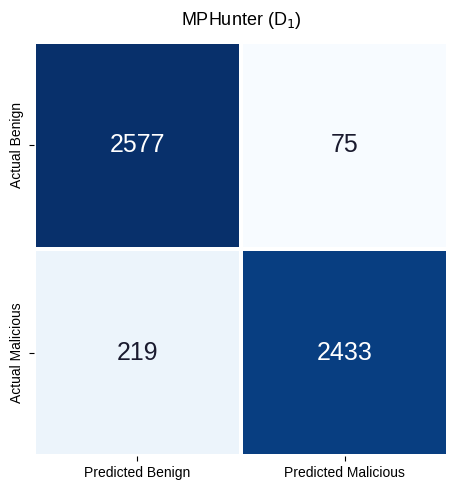

Saved → /content/drive/MyDrive/LAMPS/mphunter_output/mp_hunter_confusion_matrix.png


In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Đổi sang Arial
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial', 'Liberation Sans', 'sans-serif']

# ── 1. Load all_data từ Drive ─────────────────────────────────────────────
ALL_DATA_FILE = DATA_DIR / 'all_data.jsonl'

all_data = load_jsonl(ALL_DATA_FILE)
print(f'Full dataset: {len(all_data)} samples')
print(f'  Malicious : {sum(1 for d in all_data if d["target"]==1)}')
print(f'  Benign    : {sum(1 for d in all_data if d["target"]==0)}')

# ── 2. Encode + Predict ───────────────────────────────────────────────────
all_empty_d, all_ne_d = split_empty_nonempty(all_data)
X_all_ne   = np.array([encode(extract_api_sequence(d['func'])) for d in all_ne_d])
all_labels = np.array([d['target'] for d in all_data])

y_pred_all = predict_full(all_data, X_all_ne)
y_true_all = all_labels

# ── 3. Metrics ────────────────────────────────────────────────────────────
acc_all  = accuracy_score(y_true_all, y_pred_all)
p_all, r_all, f1_all, _ = precision_recall_fscore_support(
    y_true_all, y_pred_all, average='binary', pos_label=1
)
cm_all = confusion_matrix(y_true_all, y_pred_all)

print(f'\nFull dataset metrics:')
print(f'  Accuracy  : {acc_all*100:.2f}%')
print(f'  Precision : {p_all:.3f}')
print(f'  Recall    : {r_all:.3f}')
print(f'  F1        : {f1_all:.3f}')

# ── 4. Vẽ Confusion Matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(
    cm_all,
    annot=False,
    cmap='Blues',
    cbar=False,
    xticklabels=['Predicted Benign', 'Predicted Malicious'],
    yticklabels=['Actual Benign',    'Actual Malicious'],
    linewidths=1.5,
    linecolor='white',
    square=True,
    ax=ax
)

for i in range(2):
    for j in range(2):
        val   = cm_all[i, j]
        color = 'white' if (i == j) else '#1a1a2e'
        ax.text(j + 0.5, i + 0.5, f'{val}',
                ha='center', va='center',
                fontsize=18,
                fontweight='normal',
                color=color)

ax.set_ylabel('', fontsize=0)
ax.set_xlabel('', fontsize=0)

ax.set_xticklabels(['Predicted Benign', 'Predicted Malicious'],
                   fontsize=10, fontweight='normal')
ax.set_yticklabels(['Actual Benign', 'Actual Malicious'],
                   fontsize=10, fontweight='normal',
                   rotation=90, va='center')

ax.set_title('MPHunter (D$_1$)',
             fontsize=13, fontweight='normal', pad=12)

plt.tight_layout()

cm_path = OUTPUT_DIR / 'mp_hunter_confusion_matrix.png'
plt.savefig(cm_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print(f'Saved → {cm_path}')